# Assess the index of MLD between EN4 and the hindcast experiment

Wanting to see if the variability in the obs product is the same as that in my JRA55 hindcast forcing NEMO-PISCES. If it's not, then some of the variation in MLD in my hindcast could be due to an underlying model drift?

In [18]:
import sys
import os
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import glob
import gsw as gsw

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# Ensure we are in the correct directory
os.chdir("/home/581/pjb581/analysis_samw")
print(os.getcwd())

print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("gsw version =", gsw.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)

print(datetime.now())

"""
NOTE: Need read permissions for group ia39
"""

/home/581/pjb581/analysis_samw
python version = 3.10.
numpy version = 2.1.3
xarray version = 2024.11.0
scipy version = 1.15.1
gsw version = 3.6.19
matplotlib version = 3.10.0
cmocean version = v3.0.3
cartopy version = 0.24.0
2025-03-06 15:44:10.350884


'\nNOTE: Need read permissions for group ia39\n'

## Load I+ timeseries

In [19]:
%%time

datapath = "/home/581/pjb581/analysis_samw"

Ipos_pac_EN4 = xr.open_dataset(datapath + "/Ipos_pac_EN4_2005-2022.nc").squeeze()
Ipos_ind_EN4 = xr.open_dataset(datapath + "/Ipos_ind_EN4_2005-2022.nc").squeeze()

Ipos_pac_sim = xr.open_dataset(datapath + "/Ipos_pac_2005-2022.nc").squeeze()
Ipos_ind_sim = xr.open_dataset(datapath + "/Ipos_ind_2005-2022.nc").squeeze()

Ipos_pac_EN4 = Ipos_pac_EN4["I_MLD"]
Ipos_ind_EN4 = Ipos_ind_EN4["I_MLD"]
Ipos_pac_sim = Ipos_pac_sim["I_MLD"]
Ipos_ind_sim = Ipos_ind_sim["I_MLD"]


CPU times: user 25.2 ms, sys: 4.05 ms, total: 29.2 ms
Wall time: 60.3 ms


## Plot timeseries and compute correlations

In [20]:
### Pearson's correlation
df_ind = pd.DataFrame({
    "Ipos_ind_EN4":Ipos_ind_EN4.rolling(time=12, center=True).mean().values,
    "Ipos_ind_sim":Ipos_ind_sim.rolling(time=12, center=True).mean().values
}, index = Ipos_ind_EN4.rolling(time=12, center=True).mean().coords['time'].values)
df_pac = pd.DataFrame({
    "Ipos_pac_EN4":Ipos_pac_EN4.rolling(time=12, center=True).mean().values,
    "Ipos_pac_sim":Ipos_pac_sim.rolling(time=12, center=True).mean().values
}, index = Ipos_pac_EN4.rolling(time=12, center=True).mean().coords['time'].values)

corr_ind = df_ind.corr()
corr_pac = df_pac.corr()

print(corr_ind)
print(corr_pac)

              Ipos_ind_EN4  Ipos_ind_sim
Ipos_ind_EN4      1.000000      0.719731
Ipos_ind_sim      0.719731      1.000000
              Ipos_pac_EN4  Ipos_pac_sim
Ipos_pac_EN4      1.000000      0.784073
Ipos_pac_sim      0.784073      1.000000


Text(0.1, 1.05, 'South Pacific Ocean')

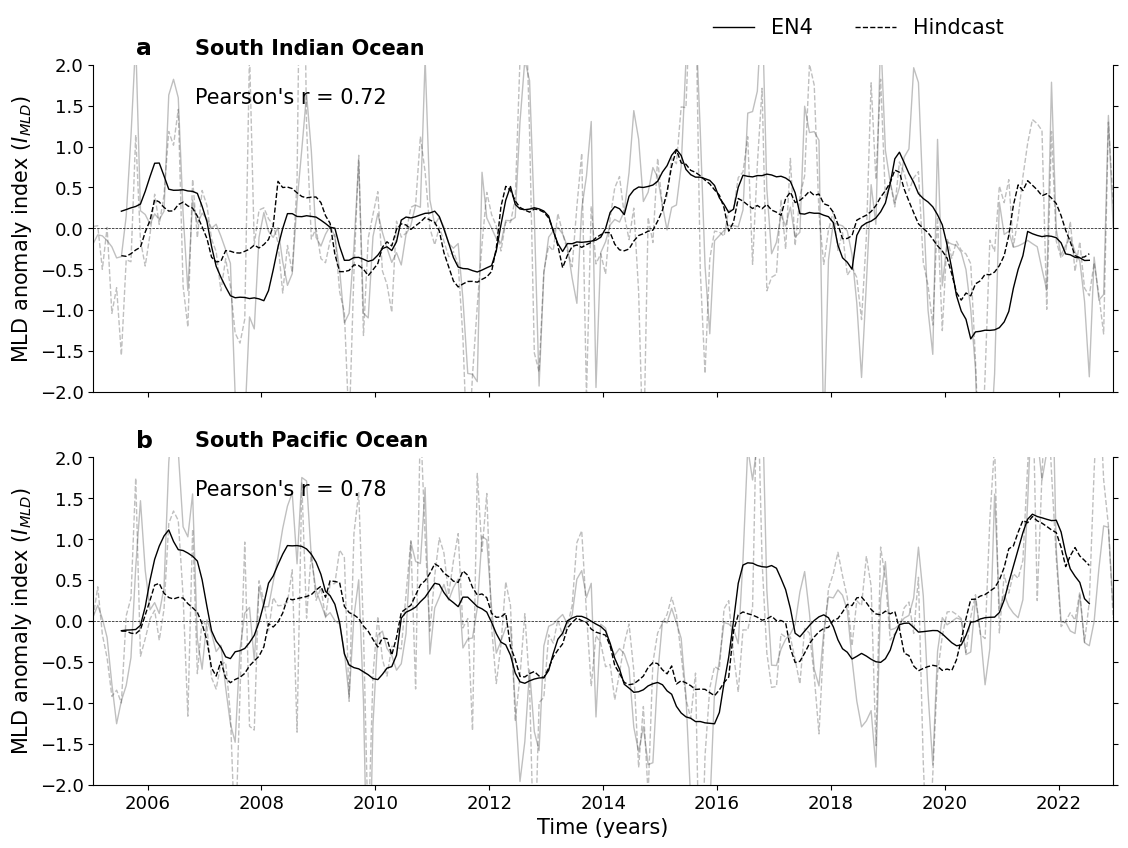

In [22]:
#%% Figure 1 (EN4)

time = Ipos_ind_EN4.coords['time']

fstic = 13
fslab = 15
wid = 1.0
lsty = ['-', '--']
cols = ['k', 'k']

fig = plt.figure(figsize=(12,8), facecolor='w')
gs = GridSpec(2,1)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[1,0])

ax1.tick_params(labelsize=fstic, right=True, labelbottom=False)
ax2.tick_params(labelsize=fstic, right=True)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.plot(time, Ipos_ind_EN4*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax1.plot(time, Ipos_ind_EN4, color=cols[0], linewidth=1.0, linestyle=lsty[0], alpha=0.25)
ax1.plot(time, Ipos_ind_sim, color=cols[1], linewidth=1.0, linestyle=lsty[1], alpha=0.25)
ax1.plot(time, Ipos_ind_EN4.rolling(time=12, center=True).mean(), color=cols[0], linewidth=1.0, linestyle=lsty[0], label="EN4")
ax1.plot(time, Ipos_ind_sim.rolling(time=12, center=True).mean(), color=cols[1], linewidth=1.0, linestyle=lsty[1], label="Hindcast")

ax2.plot(time, Ipos_pac_EN4, color=cols[0], linewidth=1.0, linestyle=lsty[0], alpha=0.25)
ax2.plot(time, Ipos_pac_sim, color=cols[1], linewidth=1.0, linestyle=lsty[1], alpha=0.25)
ax2.plot(time, Ipos_pac_EN4*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax2.plot(time, Ipos_pac_EN4.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle=lsty[0])
ax2.plot(time, Ipos_pac_sim.rolling(time=12, center=True).mean(), color=cols[1], linewidth=1.0, linestyle=lsty[1])

ax1.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.75,1.2), ncols=2)

ax1.set_xlim(time.min(), time.max())
ax2.set_xlim(time.min(), time.max())
ax2.set_xlabel("Time (years)", fontsize=fslab)
ax1.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax2.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)

xx = 0.1; yy = 0.9
plt.text(xx,yy, "Pearson's r = %.2f"%(corr_ind.values[0,1]), fontsize=fslab, ha='left', va='center', transform=ax1.transAxes)
plt.text(xx,yy, "Pearson's r = %.2f"%(corr_pac.values[0,1]), fontsize=fslab, ha='left', va='center', transform=ax2.transAxes)

ax1.set_ylim(-2.0,2.0)
ax2.set_ylim(-2.0,2.0)

plt.subplots_adjust(left=0.1, top=0.95, right=0.95, bottom=0.05)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)

xx = 0.10; yy = 1.05
plt.text(xx,yy,'South Indian Ocean', fontweight='bold', fontsize=fslab, va='center', ha='left', transform=ax1.transAxes)
plt.text(xx,yy,'South Pacific Ocean', fontweight='bold', fontsize=fslab, va='center', ha='left', transform=ax2.transAxes)


In [23]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-Ipos_compare_EN4-hindcast.png', dpi=300, bbox_inches='tight')
